In [ ]:
# Model to predict categories of all objects - Good predictions

In [53]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

# Importation pour la transformation sur les images
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import Resizing
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomBrightness
from tensorflow.keras.layers import RandomContrast
from tensorflow.keras.layers import RandomTranslation 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Importation de l'utilitaire image_dataset_from_directory de Keras
from keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
import tensorflow as tf
from tensorflow.keras import layers, models

# Importation pour les visualisations
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from imblearn.metrics import classification_report_imbalanced

from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from collections import Counter

In [ ]:
# Multi-category prediction - Notes
Conv2D + Dense layes is able to predict categories well with 3 epochs
3 Con2D layers complicate and reaches upto 7 epochs to predict categories well

In [4]:
# Get data
#df = pd.read_csv("Data/mvtec_full_images_colour.csv")
#df.head()
df = pd.read_pickle("Data/mvtec_full_images_colour.pkl")
#df.shape
df.head()

,file_path,category_name,dir_name,file_name,file_size,label,img
0,..\Projects\mvtec_anomaly_detection\bottle\tes...,bottle,broken_large,000.png,526002,1,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
1,..\Projects\mvtec_anomaly_detection\bottle\tes...,bottle,broken_large,001.png,525657,1,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
2,..\Projects\mvtec_anomaly_detection\bottle\tes...,bottle,broken_large,002.png,515614,1,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
3,..\Projects\mvtec_anomaly_detection\bottle\tes...,bottle,broken_large,003.png,488569,1,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."
4,..\Projects\mvtec_anomaly_detection\bottle\tes...,bottle,broken_large,004.png,549987,1,"[[[255, 255, 255], [255, 255, 255], [255, 255,..."


In [9]:
# Multi-categories prediction

X=df['img']
y=df['category_name']
X = np.stack(X).astype(np.float32)  # now shape: (num_samples,256,256,3)
X = X / 255.0  

print(type(X))           # should be <class 'numpy.ndarray'>
print(X.dtype)           # should be float32 or float64, NOT object
print(X.shape)           # should be (num_samples, 256, 256, 3)

le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)
print(num_classes)
print(y_encoded)

# Split into train and validation
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train shape:", X_train.shape, "Validation shape:", X_test.shape)
print(X_test[0].shape)

<class 'numpy.ndarray'>
float32
(5346, 256, 256, 3)
15
[ 0  0  0 ... 14 14 14]
Train shape: (4276, 256, 256, 3) Validation shape: (1070, 256, 256, 3)
(256, 256, 3)


In [128]:
y_encoded[5000:5050]

array([14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14])

Epoch 1/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 136s 994ms/step - accuracy: 0.9006 - loss: 0.4081 - val_accuracy: 0.9860 - val_loss: 0.0301 - learning_rate: 0.0010
Epoch 2/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.9822 - loss: 0.0664 - val_accuracy: 0.7776 - val_loss: 1.0797 - learning_rate: 0.0010
Epoch 3/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 399s 3s/step - accuracy: 0.9607 - loss: 0.1326 - val_accuracy: 0.9953 - val_loss: 0.0144 - learning_rate: 0.0010
Epoch 4/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.9857 - loss: 0.0368 - val_accuracy: 0.9991 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 5/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 133s 993ms/step - accuracy: 1.0000 - loss: 4.1039e-04 - val_accuracy: 1.0000 - val_loss: 3.7490e-04 - learning_rate: 0.0010
Epoch 6/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 1.0000 - loss: 1.3530e-04 - val_accuracy: 1.0000 - val_loss: 2.6066e-04 - learning_rate: 0.0010
Epoch 7/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 944ms/step - accu

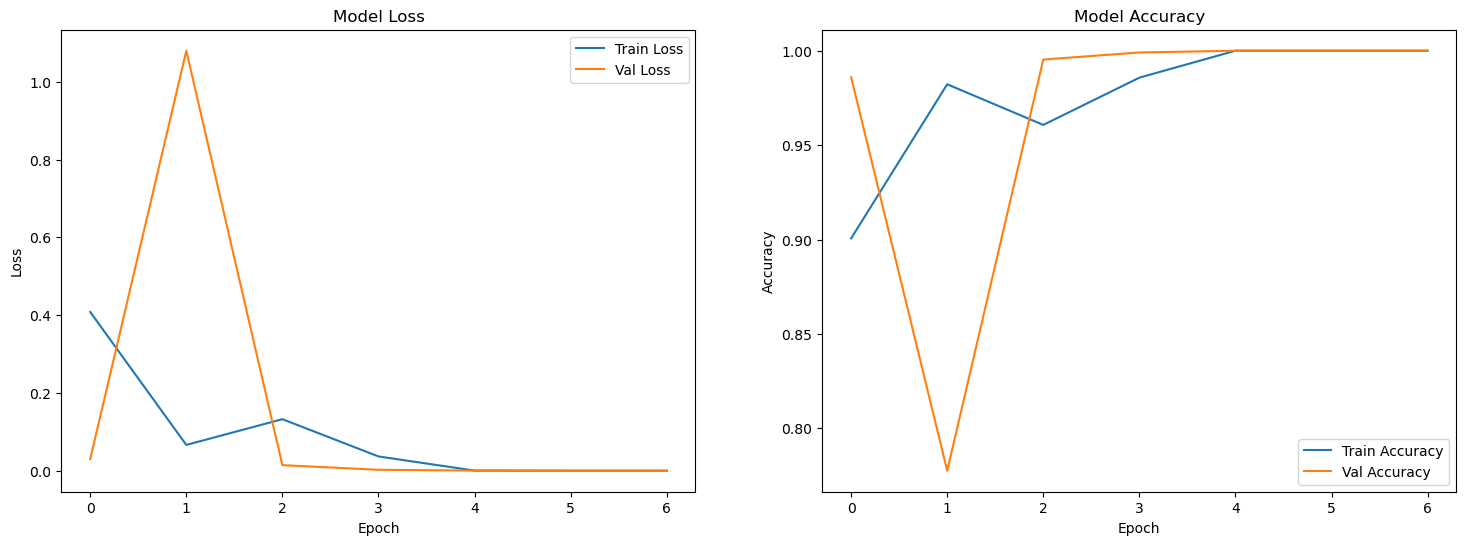

34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 222ms/step
Validation Accuracy: 1.0000


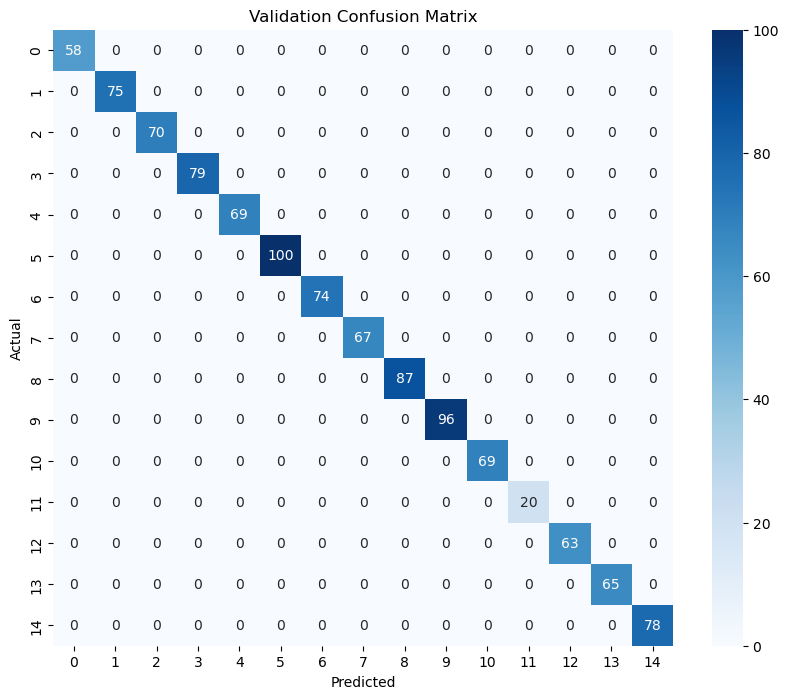

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        58
           1       1.00      1.00      1.00        75
           2       1.00      1.00      1.00        70
           3       1.00      1.00      1.00        79
           4       1.00      1.00      1.00        69
           5       1.00      1.00      1.00       100
           6       1.00      1.00      1.00        74
           7       1.00      1.00      1.00        67
           8       1.00      1.00      1.00        87
           9       1.00      1.00      1.00        96
          10       1.00      1.00      1.00        69
          11       1.00      1.00      1.00        20
          12       1.00      1.00      1.00        63
          13       1.00      1.00      1.00        65
          14       1.00      1.00      1.00        78

    accuracy                           1.00      1070
   macro avg       1.00      1.00      1.00      1070
weighted avg       1.00   

In [10]:
# Predict categories with 3 Con2D layers
model = models.Sequential([
    layers.Input(shape=(256,256,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')  # output layer
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # use integer labels
    metrics=['accuracy']
)
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,callbacks = [reduce_learning_rate,
                                       early_stopping]
)
model.save('Models/model_predict_cat_simple_conv3.keras')
display_loss_accuracy_graph(history)
display_evaluation_metrics(model)

Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 83s 606ms/step - accuracy: 0.8786 - loss: 3.0104 - val_accuracy: 0.9991 - val_loss: 0.0067 - learning_rate: 0.0010
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 80s 598ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 3/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 1.0000 - loss: 5.4483e-04
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
134/134 ━━━━━━━━━━━━━━━━━━━━ 79s 588ms/step - accuracy: 1.0000 - loss: 4.9858e-04 - val_accuracy: 1.0000 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 3: early stopping


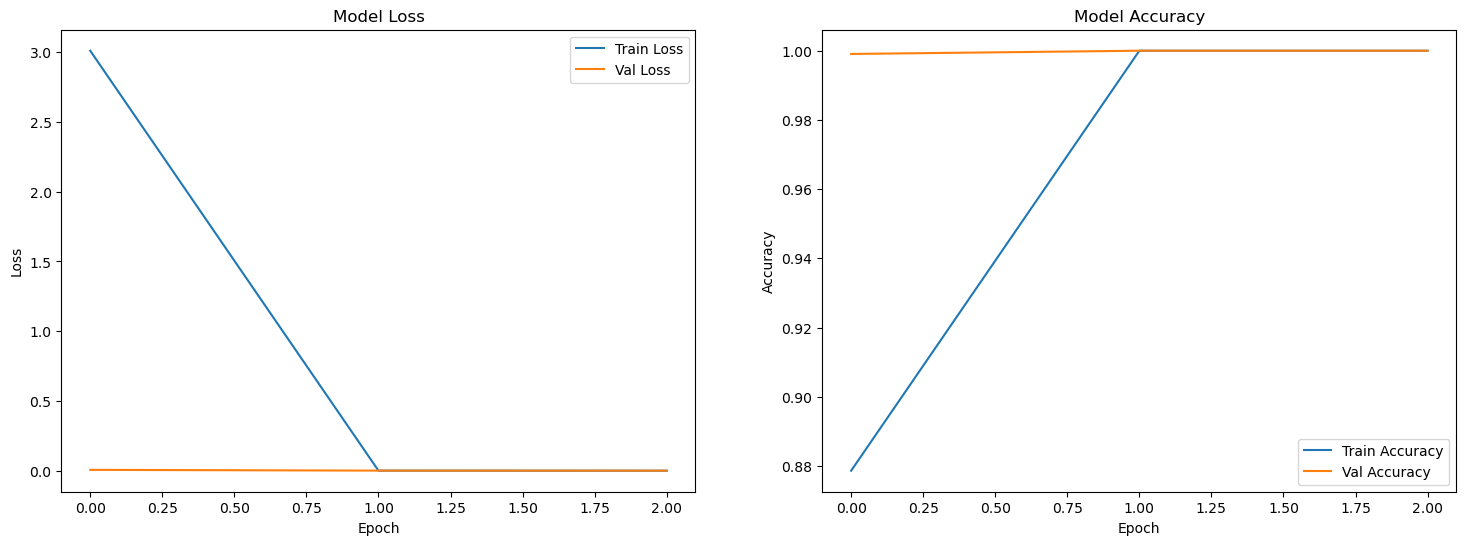

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step
Validation Accuracy: 1.0000


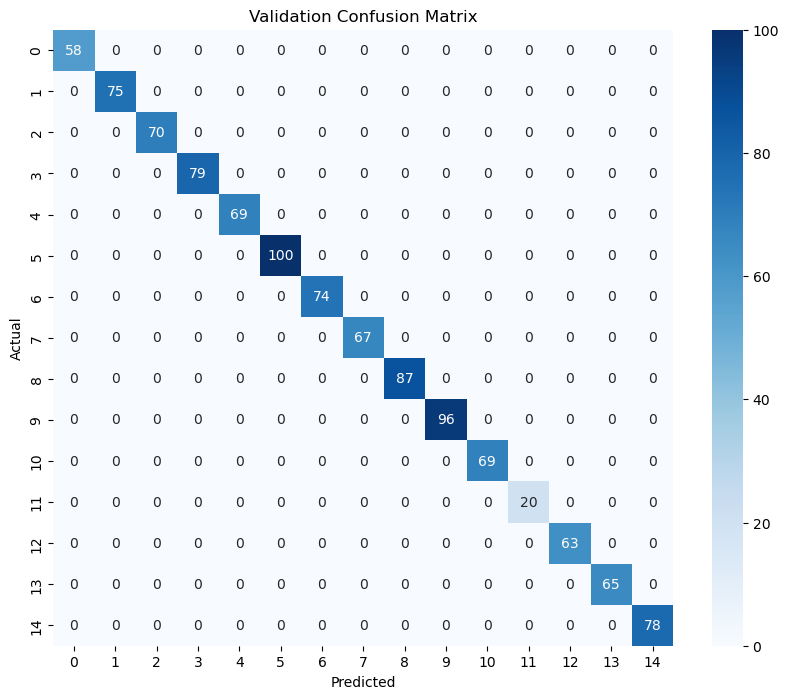

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        58
           1       1.00      1.00      1.00        75
           2       1.00      1.00      1.00        70
           3       1.00      1.00      1.00        79
           4       1.00      1.00      1.00        69
           5       1.00      1.00      1.00       100
           6       1.00      1.00      1.00        74
           7       1.00      1.00      1.00        67
           8       1.00      1.00      1.00        87
           9       1.00      1.00      1.00        96
          10       1.00      1.00      1.00        69
          11       1.00      1.00      1.00        20
          12       1.00      1.00      1.00        63
          13       1.00      1.00      1.00        65
          14       1.00      1.00      1.00        78

    accuracy                           1.00      1070
   macro avg       1.00      1.00      1.00      1070
weighted avg       1.00   

In [19]:
# Predict categories with one simple Con2D layer
inputs = Input(shape=(256,256,3))
#x=Rescaling(1./255)(inputs)
x=Conv2D(32, (3,3),activation='relu')(inputs)
x=MaxPooling2D((2,2))(x)
x=Flatten()(x)
x=Dense(128,activation='relu')(x)
outputs=Dense(15, activation='softmax')(x)
model= Model(inputs=inputs, outputs=outputs )

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # use integer labels
    metrics=['accuracy']
)
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,callbacks = [reduce_learning_rate,
                                       early_stopping]
)
model.save('Models/model_predict_cat_simple_conv1.keras')
display_loss_accuracy_graph(history)
display_evaluation_metrics(model)

In [130]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # use integer labels
    metrics=['accuracy']
)
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)
model.save('Models/model_predict_cat_simple_conv3.keras')
display_loss_accuracy_graph(history)
display_evaluation_metrics(model)

In [2]:
def display_loss_accuracy_graph(model_history):
    train_loss = model_history.history["loss"]
    val_loss = model_history.history["val_loss"]
    train_acc = model_history.history["accuracy"]
    val_acc = model_history.history["val_accuracy"]

    plt.figure(figsize=(18,6))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(train_loss, label='Train Loss')
    plt.plot(val_loss, label='Val Loss')
    plt.title("Model Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(val_acc, label='Val Accuracy')
    plt.title("Model Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()


In [80]:
def display_evaluation_metrics(model):
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    val_acc = accuracy_score(y_test, y_pred)
    print(f"Validation Accuracy: {val_acc:.4f}")
    
    val_cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10,8))
    sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Validation Confusion Matrix")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()
    
    print(classification_report(y_test, y_pred, target_names = class_names))
    print(classification_report_imbalanced(y_test, y_pred, target_names = class_names))


    print("True labels:", Counter(y_test))
    print("Predicted labels:", Counter(y_pred))


In [5]:
early_stopping = EarlyStopping(
                                patience=3, # Attendre 5 epochs avant application
                                min_delta=0.01, # si au bout de 5 epochs la fonction de perte ne varie pas de 1%, 
    # que ce soit à la hausse ou à la baisse, on arrête
                                verbose=1, # Afficher à quel epoch on s'arrête
                                mode='min',
                                monitor='val_loss')

reduce_learning_rate = ReduceLROnPlateau(
                                    monitor="val_loss",
                                    patience=3, # si val_loss stagne sur 3 epochs consécutives selon la valeur min_delta
                                    min_delta=0.01,
                                    factor=0.1,  # On réduit le learning rate d'un facteur 0.1
                                    cooldown=4,  # On attend 4 epochs avant de réitérer 
                                    verbose=1)